# 09 · Anexo: ¿cuánto del techo que queda es del proveedor?

**Qué pregunta responde este cuaderno.** El sistema `final` acierta 12 de 20 preguntas del golden propio.
De las ocho que falla, ¿cuántas son culpa del agente y cuántas son culpa del proveedor que le da el
«cerebro»?

Las tres réplicas del sistema `final` medidas con el modelo gratuito dan todas *micro* 60 %, pero cada una
falla una familia distinta: la tanda oficial se deja 1 de 7 comparativas y las réplicas se dejan 5 de 6
extractivas. Mirando las predicciones se ve por qué: entre 0 y 6 preguntas por tanda terminan en
`PlazoAgotado`, es decir, el proveedor nunca devolvió la respuesta. Eso apunta a que el límite no está en
cómo razona el agente sino en quién lo ejecuta, pero *apuntar* no es *medir*.

Este anexo lo mide. Repite exactamente la misma medición cambiando **una sola cosa**: el modelo. Todo lo
demás —sistema, golden, retrieval, prompts, guardrails, plazo, juez— se queda clavado. Si la hipótesis es
buena, las familias que se caían por plazos agotados deben recuperarse; si además se mueven las que no se
caían por tiempo, entonces parte del techo era *capacidad* del modelo y no *fiabilidad* del proveedor, y eso
es un hallazgo distinto que hay que contar igual.

> **El sistema entregado sigue siendo `final` con el modelo gratuito, medido en `resultados/final/`. Este
> cuaderno es una ablación de proveedor, no una nota mejor.**

**Requisitos:** R11, R12 y R15 ([01](../docs/01_requisitos_y_contratos.md)) · **Guía:** [13 §8](../docs/13_skill_medicion_informe_presentacion.md)
**Entradas:** `golden/golden_propio.jsonl`, `golden/golden_huecos.jsonl` · **Salidas:** `resultados/{final,baseline}_pago[_huecos]/`, `resultados/final_jp[_huecos]/`
Con `EJECUTAR = False` no se llama a ninguna API: se lee lo que ya está guardado en disco.

In [1]:
# Arranque (igual en todos los notebooks): localiza la raíz del repo y hace importable src/
import sys, pathlib, json
RAIZ = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "pyproject.toml").exists())
if str(RAIZ / "src") not in sys.path:
    sys.path.insert(0, str(RAIZ / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from agente10k import config, evaluacion, evaluadores

plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold",
                     "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

# Gris = proveedor gratuito, verde = proveedor de pago. Se mantiene en todas las figuras del cuaderno.
COLOR_GRATIS, COLOR_PAGO = "#bdbdbd", "#1f8a4c"
COLOR_FAMILIA = {"numerica": "#4C78A8", "extractiva": "#59A14F",
                 "comparativa": "#F28E2B", "hueco": "#8F63B8"}

print("resultados en:", config.RESULTADOS)
print("Este cuaderno NO llama a ninguna API con EJECUTAR = False.")

resultados en: C:\Users\Usuario\Downloads\10k-financial-agent\resultados
Este cuaderno NO llama a ninguna API con EJECUTAR = False.


In [2]:
# Parámetros
EJECUTAR = False  # True: llama al modelo (gasta API y pide clave). False: reutiliza lo guardado en resultados/

MODELO_PAGO = "openrouter:google/gemini-3.8-flash"  # el modelo que fijaba el enunciado (docs/01 §4)
MODELO_GRATIS = "openrouter:nex-agi/nex-n2.5-pro:free"  # con el que se midió el sistema entregado

# Las dos filas del anexo: misma configuración, distinto modelo. Los sufijos siguen la convención
# del repo: _huecos es el golden de huecos y _jp es una RE-PUNTUACIÓN con juez de pago (no una ejecución).
GRATIS, PAGO = "final_jp", "final_pago"
PAR_R11_PAGO = ("baseline_pago", "final_pago")  # el par válido del R11 con el modelo de pago

if EJECUTAR:
    assert config.cargar_clave(), "Falta OPENROUTER_API_KEY: copia .env.example a .env y rellénala"


def _leer_json(ruta):
    """El JSON de `ruta`, o {} si falta o está a medio escribir."""
    try:
        return json.loads(pathlib.Path(ruta).read_text(encoding="utf-8"))
    except (FileNotFoundError, json.JSONDecodeError, OSError, UnicodeDecodeError):
        return {}


def _leer_jsonl(ruta):
    """Las filas de un JSONL, o [] si falta."""
    try:
        return [json.loads(x) for x in pathlib.Path(ruta).read_text(encoding="utf-8").splitlines() if x.strip()]
    except (FileNotFoundError, json.JSONDecodeError, OSError, UnicodeDecodeError):
        return []


def resumen_de(etiqueta):
    return _leer_json(config.RESULTADOS / etiqueta / "resumen.json")


def manifest_de(etiqueta):
    return _leer_json(config.RESULTADOS / etiqueta / "manifest.json")


def pendiente(*etiquetas):
    """Las etiquetas cuyo resumen todavía no existe. Si devuelve algo, la celda se salta.

    Regla 8 de CLAUDE.md: el cuaderno debe ejecutar entero con EJECUTAR=False aunque falten
    artefactos opcionales, así que cada sección de análisis empieza comprobando sus entradas.
    """
    return [e for e in etiquetas if not resumen_de(e)]


def aviso_pendiente(faltan):
    display(Markdown(f"**Pendiente:** falta `{'`, `'.join(faltan)}`. En cuanto exista, esta celda lo "
                     "incorpora sola, sin tocar código."))

## 1. El diseño: una sola variable

Una ablación solo significa algo si de verdad cambia una cosa. Aquí hay tres candidatos a contaminar la
comparación, y conviene desactivarlos antes de mirar ningún número:

| Candidato a contaminar | Por qué podría | Cómo se neutraliza |
| --- | --- | --- |
| El retrieval | Si dependiera del modelo, cambiaría al cambiarlo | `buscar_final()` es determinista: denso + BM25 + RRF, sin ninguna llamada al LLM |
| El golden | Otra lista de preguntas, otra nota | El `manifest.json` guarda el SHA-256 del fichero; debe coincidir |
| **El juez** | `evaluar()` crea el juez con el modelo del agente si no se fija otro | Se fija `AGENTE10K_MODELO_JUEZ` al modelo de pago **en las dos filas** |

El tercero es el que más fácil se cuela. Si se cambia solo `AGENTE10K_MODELO`, cambian a la vez el agente y
el juez, y entonces una subida podría ser que el agente responde mejor o que el juez corrige más blando. Por
eso la fila gratuita del anexo no es `final` tal cual, sino `final_jp`: las **mismas predicciones** de
`resultados/final/`, re-puntuadas con el juez de pago. Lo hace `repuntuar()`, que no vuelve a llamar al
agente y no toca la carpeta de origen.

La celda siguiente comprueba las tres cosas sobre los artefactos que hay en disco.

In [3]:
import inspect
from agente10k import retrieval

filas_diseno = []
for etiqueta in ("final", "final_pago", "baseline_pago"):
    m = manifest_de(etiqueta)
    filas_diseno.append({
        "etiqueta": etiqueta,
        "sistema": m.get("sistema", "—"),
        "modelo": (m.get("modelo") or "—").replace("openrouter:", ""),
        "golden_sha256": (m.get("golden_sha256") or "—")[:12],
        "retrieval": (m.get("retrieval") or {}).get("backend", "—"),
    })
display(pd.DataFrame(filas_diseno).set_index("etiqueta"))

# El retrieval del sistema final no llama al LLM: se comprueba sobre el propio código, no de palabra.
fuente_buscar = inspect.getsource(retrieval.buscar_final)
sin_llm = not any(t in fuente_buscar for t in ("reescribir", "crear_modelo", "invoke"))

man_final, man_pago = manifest_de("final"), manifest_de("final_pago")
mismo_golden = bool(man_final.get("golden_sha256")) and man_final.get("golden_sha256") == man_pago.get("golden_sha256")
mismo_sistema = man_final.get("sistema") == man_pago.get("sistema") == "final"
distinto_modelo = bool(man_pago.get("modelo")) and man_final.get("modelo") != man_pago.get("modelo")

for ok, texto in [(sin_llm, "buscar_final() no llama al LLM: el retrieval no puede depender del modelo"),
                  (mismo_golden, "mismo golden (SHA-256 del manifest)"),
                  (mismo_sistema, "mismo sistema (final: retrieval mejorado + guardrails del 06)"),
                  (distinto_modelo, "distinto modelo: la unica variable")]:
    print(("  OK  " if ok else "  ??  ") + texto)

# La columna `retrieval` de arriba enseña dos cadenas distintas para la MISMA búsqueda: los manifiestos
# viejos la escriben "hibrido_sin_reescritura" y los nuevos "bm25", porque manifest_ejecucion() cambió de
# formato. No es que el retrieval difiera; ambas filas ejecutan el mismo crear_search_filings("final").
display(Markdown(
    "⚠️ `hibrido_sin_reescritura` (manifiesto antiguo) y `bm25` (manifiesto actual) **nombran la misma "
    "búsqueda**: las dos filas usan `crear_search_filings(\"final\")`, que es denso + BM25 + RRF. La "
    "diferencia es de formato del `manifest.json`, no de código. Lo que garantiza que el retrieval es "
    "idéntico no es esa cadena sino la comprobación de arriba: la función no hace ninguna llamada al LLM, "
    "así que cambiar de modelo no puede cambiar lo que recupera."))

,sistema,modelo,golden_sha256,retrieval
etiqueta,,,,
final,final,nex-agi/nex-n2.5-pro:free,02dfdb2b3277,hibrido_sin_reescritura
final_pago,final,google/gemini-3.8-flash,02dfdb2b3277,bm25
baseline_pago,baseline,google/gemini-3.8-flash,02dfdb2b3277,denso


  OK  buscar_final() no llama al LLM: el retrieval no puede depender del modelo
  OK  mismo golden (SHA-256 del manifest)
  OK  mismo sistema (final: retrieval mejorado + guardrails del 06)
  OK  distinto modelo: la unica variable


⚠️ `hibrido_sin_reescritura` (manifiesto antiguo) y `bm25` (manifiesto actual) **nombran la misma búsqueda**: las dos filas usan `crear_search_filings("final")`, que es denso + BM25 + RRF. La diferencia es de formato del `manifest.json`, no de código. Lo que garantiza que el retrieval es idéntico no es esa cadena sino la comprobación de arriba: la función no hace ninguna llamada al LLM, así que cambiar de modelo no puede cambiar lo que recupera.

**Qué nos dice esto:** las tres filas comparten sistema y golden, el retrieval es el mismo código
determinista, y lo único que cambia es la cadena del modelo. La comparación está limpia.

Queda una salvedad que el propio repo no detecta y conviene decir en voz alta: `tabla_r11()` avisa cuando
dos filas no comparten el modelo **del agente**, pero no mira el modelo **del juez**, porque
`_fila_comparativa()` no expone ese campo. Es decir, la herramienta no nos habría protegido de comparar
`final` con `final_pago` usando jueces distintos. Ese control lo hacemos aquí a mano, con `final_jp`.

## 2. Cómo se midieron las tandas de pago

Cuatro ejecuciones, todas con el sistema `final` o `baseline` sin tocar una línea de código: solo variables
de entorno. Se fijan las dos, la del agente y la del juez, por lo dicho arriba.

```powershell
$env:AGENTE10K_MODELO      = "openrouter:google/gemini-3.8-flash"
$env:AGENTE10K_MODELO_JUEZ = "openrouter:google/gemini-3.8-flash"
$env:AGENTE10K_PLAZO_S     = "300"   # el mismo plazo que usaron las tandas gratuitas

.venv\Scripts\python.exe -m agente10k golden/golden_propio.jsonl --etiqueta final_pago       --sistema final
.venv\Scripts\python.exe -m agente10k golden/golden_huecos.jsonl --etiqueta final_pago_huecos --sistema final
.venv\Scripts\python.exe -m agente10k golden/golden_propio.jsonl --etiqueta baseline_pago       --sistema baseline
.venv\Scripts\python.exe -m agente10k golden/golden_huecos.jsonl --etiqueta baseline_pago_huecos --sistema baseline
```

Las dos del `baseline` no son opcionales: el invariante 4 del repo dice que una comparación evaluada exige
el mismo modelo en las dos filas, así que un `final_pago` sin su `baseline_pago` no podría ponerse nunca en
una tabla del R11.

In [4]:
ETIQUETAS_PAGO = ["final_pago", "final_pago_huecos", "baseline_pago", "baseline_pago_huecos"]
faltan = [e for e in ETIQUETAS_PAGO if not resumen_de(e)]

if EJECUTAR and faltan:
    import os
    os.environ["AGENTE10K_MODELO"] = MODELO_PAGO
    os.environ["AGENTE10K_MODELO_JUEZ"] = MODELO_PAGO
    os.environ["AGENTE10K_PLAZO_S"] = "300"
    for etiqueta in faltan:
        golden = "golden_huecos.jsonl" if etiqueta.endswith("_huecos") else "golden_propio.jsonl"
        sistema = "baseline" if etiqueta.startswith("baseline") else "final"
        print(f"Ejecutando {etiqueta} ({sistema})... gasta API")
        evaluacion.evaluar(config.GOLDEN / golden, etiqueta=etiqueta, sistema=sistema)
elif not faltan:
    inventario = " · ".join(
        f"`{e}` ({resumen_de(e).get('n')} preguntas, {(resumen_de(e).get('fecha') or '')[:10]})"
        for e in ETIQUETAS_PAGO)
    display(Markdown(f"Se reutilizan las cuatro tandas ya guardadas: {inventario}."))
else:
    display(Markdown(f"**Pendiente:** faltan `{'`, `'.join(faltan)}`. Con `EJECUTAR=True` y clave, esta "
                     "celda las lanza; en cuanto existan, el resto del cuaderno las incorpora solo, "
                     "sin tocar código."))

Se reutilizan las cuatro tandas ya guardadas: `final_pago` (20 preguntas, 2026-09-23) · `final_pago_huecos` (6 preguntas, 2026-09-23) · `baseline_pago` (20 preguntas, 2026-09-23) · `baseline_pago_huecos` (6 preguntas, 2026-09-23).

## 3. El juez común

`resultados/final/` se puntuó con el modelo gratuito haciendo de juez, es decir, el agente se evaluaba a sí
mismo. Para el anexo hace falta la misma tanda vista por el juez de pago, y eso es lo que produce
`repuntuar()`: lee las predicciones ya guardadas, las vuelve a puntuar y escribe el resultado en **otra**
etiqueta. No llama al agente, no gasta más que las llamadas del juez y no puede estropear la tanda original,
porque la función se niega a escribir en la carpeta de origen.

El nombre importa: la re-puntuación de los huecos tiene que llamarse `final_jp_huecos` y no
`final_huecos_jp`, porque `tabla_r11()` busca los huecos de una etiqueta como `<etiqueta>_huecos`. Con el
otro orden, la columna de huecos saldría vacía.

In [5]:
REPUNTUACIONES = [("final", "final_jp"), ("final_huecos", "final_jp_huecos")]
faltan_jp = [d for _, d in REPUNTUACIONES if not resumen_de(d)]

if EJECUTAR and faltan_jp:
    juez_pago = evaluadores.crear_juez(MODELO_PAGO)
    for origen, destino in REPUNTUACIONES:
        if not resumen_de(destino):
            print(f"Re-puntuando {origen} -> {destino} con juez de pago...")
            evaluadores.repuntuar(origen, juez=juez_pago, guardar_en=destino)
    juez_pago.guardar()
elif not faltan_jp:
    jp = resumen_de("final_jp")
    display(Markdown(
        f"`final_jp` ya existe: son las **mismas predicciones** de `{jp.get('repuntuado_de', 'final')}` "
        f"({jp.get('n')} preguntas) puntuadas por `{(jp.get('juez') or {}).get('modelo', '—')}`."))
else:
    display(Markdown(f"**Pendiente:** falta `{'`, `'.join(faltan_jp)}`. Con `EJECUTAR=True` esta celda "
                     "re-puntúa las tandas gratuitas con el juez de pago."))

# Control explícito de que la única variable es el agente: el juez debe ser el mismo en las dos filas.
juez_gratis = (resumen_de(GRATIS).get("juez") or {}).get("modelo", "—")
juez_pago_id = (resumen_de(PAGO).get("juez") or {}).get("modelo", "—")
agente_gratis = resumen_de(GRATIS).get("modelo", "—")
agente_pago = resumen_de(PAGO).get("modelo", "—")
display(pd.DataFrame(
    [{"fila": GRATIS, "modelo del agente": agente_gratis, "modelo del juez": juez_gratis},
     {"fila": PAGO, "modelo del agente": agente_pago, "modelo del juez": juez_pago_id}]).set_index("fila"))
print(("  OK   mismo juez en las dos filas: la única variable es el agente"
       if juez_gratis == juez_pago_id else
       "  ??   jueces distintos: la comparación NO sería atribuible al agente"))

`final_jp` ya existe: son las **mismas predicciones** de `final` (20 preguntas) puntuadas por `openrouter:google/gemini-3.8-flash`.

,modelo del agente,modelo del juez
fila,,
final_jp,nex-agi/nex-n2.5-pro:free,openrouter:google/gemini-3.8-flash
final_pago,google/gemini-3.8-flash,openrouter:google/gemini-3.8-flash


  OK   mismo juez en las dos filas: la única variable es el agente


## 4. La tabla del anexo

Dos filas, mismo sistema, mismo juez, distinto modelo.

Una trampa de lectura que hay que neutralizar antes de enseñar esta tabla: la columna de coste marca como
mejor el valor **más bajo**, y el proveedor gratuito reporta `0,00` USD. Es un cero de verdad, no un dato
ausente, así que la fila gratuita gana siempre esa columna. Leída sin cuidado, la tabla dice «lo gratis sale
mejor y es más barato», que es justo lo contrario de lo que mide el anexo. Por eso el coste se comenta
aparte, en §7.

In [6]:
import warnings

faltan = pendiente(GRATIS, PAGO)
if faltan:
    aviso_pendiente(faltan)
else:
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # el aviso de "no comparten modelo" es esperado y se comenta abajo
        anexo = evaluacion.tabla_r11((GRATIS, PAGO))

    display(anexo.drop(columns=["recall@5"], errors="ignore"))
    display(Markdown(f"*{anexo.attrs['nota']}* Es el comportamiento correcto: `tabla_r11()` se niega a "
                     "coronar un ganador entre modelos distintos, porque eso no sería una comparación de "
                     "sistemas."))

    comp = evaluacion.tabla_comparativa((GRATIS, PAGO)).set_index("sistema")
    fmt = lambda v, u: "—" if v is None or (isinstance(v, float) and np.isnan(v)) else (
        f"{v:.4f}{u}" if u == " USD" else f"{v:,.2f}{u}")
    for clave, titulo, unidad in [("micro", "micro", ""), ("recall_agente", "recall del agente", ""),
                                  ("errores", "preguntas perdidas por el proveedor", ""),
                                  ("latencia_media_s", "latencia media", " s"),
                                  ("usd_medio", "coste por pregunta", " USD")]:
        a, b = comp.loc[GRATIS, clave], comp.loc[PAGO, clave]
        print(f"{titulo:38} gratis {fmt(a, unidad):>12}   ->   pago {fmt(b, unidad):>12}")

,sistema,modelo,numérica,extractiva,comparativa,hueco,micro,coste USD/pregunta,latencia media (s),latencia mediana (s),tokens/pregunta,llamadas/pregunta
0,final_jp,nex-agi/nex-n2.5-pro:free,7/7,4/6,1/7,6/6,0.60,0.00,168.84,171.77,"6,067.80",1.90
1,final_pago,google/gemini-3.8-flash,7/7,4/6,4/7,6/6,0.75,0.02,26.58,21.60,"15,092.80",2.20


*Sin marcas: las filas no comparten modelo.* Es el comportamiento correcto: `tabla_r11()` se niega a coronar un ganador entre modelos distintos, porque eso no sería una comparación de sistemas.

micro                                  gratis         0.60   ->   pago         0.75
recall del agente                      gratis         0.77   ->   pago         0.92
preguntas perdidas por el proveedor    gratis         6.00   ->   pago         0.00
latencia media                         gratis     168.84 s   ->   pago      26.58 s
coste por pregunta                     gratis   0.0000 USD   ->   pago   0.0191 USD


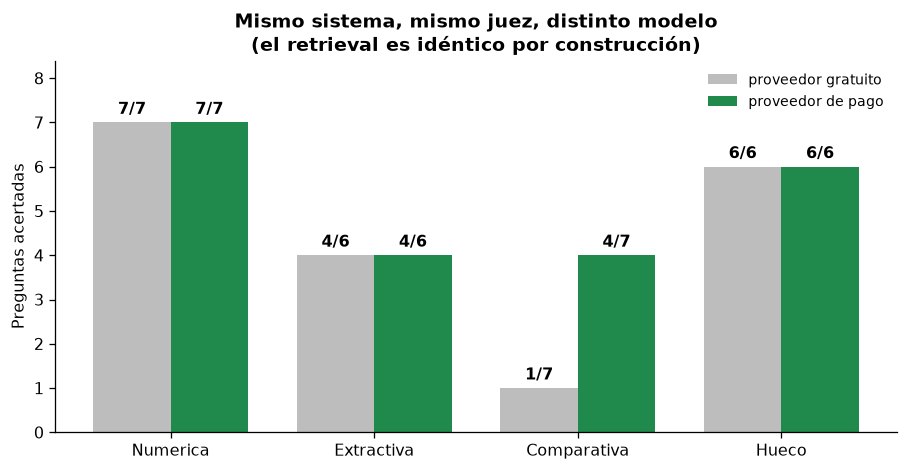

In [7]:
familias = ["numerica", "extractiva", "comparativa", "hueco"]
totales = {"numerica": 7, "extractiva": 6, "comparativa": 7, "hueco": 6}


def aciertos(etiqueta, familia):
    """k de la cadena 'k/n' del resumen; los huecos viven en la etiqueta <etiqueta>_huecos."""
    origen = resumen_de(f"{etiqueta}_huecos") if familia == "hueco" else resumen_de(etiqueta)
    valor = (origen.get("familias") or {}).get(familia)
    return int(valor.split("/")[0]) if isinstance(valor, str) and "/" in valor else np.nan


faltan = pendiente(GRATIS, PAGO)
if faltan:
    aviso_pendiente(faltan)
else:
    g = [aciertos(GRATIS, f) for f in familias]
    p = [aciertos(PAGO, f) for f in familias]
    x, ancho = np.arange(len(familias)), 0.38

    fig, ax = plt.subplots(figsize=(8, 4.2))
    b1 = ax.bar(x - ancho / 2, g, ancho, label="proveedor gratuito", color=COLOR_GRATIS)
    b2 = ax.bar(x + ancho / 2, p, ancho, label="proveedor de pago", color=COLOR_PAGO)
    for barras, valores in ((b1, g), (b2, p)):
        ax.bar_label(barras, labels=[f"{v:.0f}/{totales[f]}" if v == v else "—"
                                     for v, f in zip(valores, familias)], padding=3, fontweight="bold")
    ax.set_xticks(x, [f.capitalize() for f in familias])
    ax.set_ylabel("Preguntas acertadas")
    ax.set_ylim(0, max(totales.values()) + 1.4)
    ax.set_title("Mismo sistema, mismo juez, distinto modelo\n(el retrieval es idéntico por construcción)")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

**Qué nos dice esto:** el *micro* pasa de 60 % a 75 %, y el reparto dice exactamente de dónde sale. Las
numéricas ya estaban al máximo y siguen en 7/7. Las extractivas **no se mueven**: 4/6 con los dos
proveedores. Todo el salto está en las comparativas, 1/7 → 4/7, que son justo las que se caían por plazos
agotados. Las preguntas perdidas por el proveedor pasan de 6 a 0.

Conviene fijarse en dos columnas más, porque son las que cierran el argumento:

- **El juez es el mismo en las dos filas** y aun así la fila gratuita puntúa 60 %, exactamente lo mismo que
  puntuaba con el juez gratuito. Cambiar de juez no movió ni una pregunta: el salto no se debe a un
  corrector más blando.
- **`recall_agente` sube de 0,77 a 0,92** con un retrieval que es el mismo código determinista. Lo que
  mejora no es el buscador sino la consulta que el agente le pasa y los filtros que elige.

## 5. Dónde estaba el techo: pregunta a pregunta

La tabla agregada dice cuánto se mueve; esta sección dice **qué** se mueve. Cada pregunta se clasifica en
uno de cuatro casos, y cada caso tiene una lectura distinta:

| Caso | Qué significa |
| --- | --- |
| **Recuperada** | Fallaba con el gratuito y acierta con el de pago: el techo era del proveedor |
| **Estable** | Acierta en las dos: la mejora del agente ya estaba y no dependía del modelo |
| **Perdida** | Acertaba y deja de acertar: ruido o regresión del modelo nuevo |
| **Irreductible** | Falla en las dos: el techo es del agente, del retrieval o del golden |

Las irreductibles son las interesantes para la defensa: son las que ningún proveedor arregla.

In [8]:
def puntuaciones_de(etiqueta):
    filas = _leer_jsonl(config.RESULTADOS / etiqueta / "puntuaciones.jsonl")
    return {f["id"]: f for f in filas}


detalle = pd.DataFrame()
faltan = pendiente(GRATIS, PAGO)
if faltan:
    aviso_pendiente(faltan)
else:
    pg, pp = puntuaciones_de(GRATIS), puntuaciones_de(PAGO)
    err_g = {f["id"]: f.get("error") for f in _leer_jsonl(config.RESULTADOS / "final" / "predicciones.jsonl")}
    err_p = {f["id"]: f.get("error") for f in _leer_jsonl(config.RESULTADOS / PAGO / "predicciones.jsonl")}

    filas = []
    for qid in sorted(set(pg) | set(pp)):
        a, b = pg.get(qid, {}).get("acierto"), pp.get(qid, {}).get("acierto")
        caso = ("Recuperada" if not a and b else "Estable" if a and b
                else "Perdida" if a and not b else "Irreductible")
        filas.append({"id": qid,
                      "familia": pg.get(qid, {}).get("familia") or pp.get(qid, {}).get("familia"),
                      "gratis": "OK" if a else "fallo", "pago": "OK" if b else "fallo", "caso": caso,
                      "plazo agotado (gratis)": "sí" if "Plazo" in str(err_g.get(qid)) else "",
                      "plazo agotado (pago)": "sí" if "Plazo" in str(err_p.get(qid)) else ""})

    detalle = pd.DataFrame(filas).set_index("id")
    display(detalle)
    display(Markdown("**Reparto:** " + " · ".join(
        f"{k} {v}" for k, v in detalle["caso"].value_counts().items())))

,familia,gratis,pago,caso,plazo agotado (gratis),plazo agotado (pago)
id,,,,,,
g3-001,numerica,OK,OK,Estable,,
g3-002,numerica,OK,OK,Estable,,
g3-003,numerica,OK,OK,Estable,,
g3-004,numerica,OK,OK,Estable,,
g3-005,numerica,OK,OK,Estable,,
g3-006,numerica,OK,OK,Estable,,
g3-007,numerica,OK,OK,Estable,,
g3-008,extractiva,OK,OK,Estable,,
g3-009,extractiva,fallo,fallo,Irreductible,,


**Reparto:** Estable 11 · Irreductible 4 · Recuperada 4 · Perdida 1

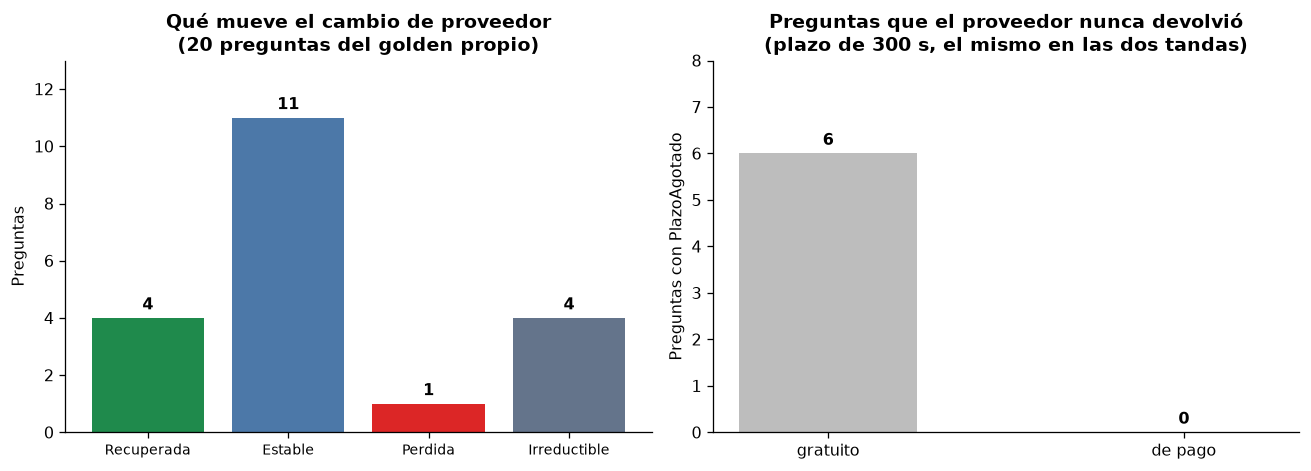

In [9]:
if detalle.empty:
    display(Markdown("**Pendiente:** sin el desglose de la celda anterior no hay figura que dibujar."))
else:
    orden = ["Recuperada", "Estable", "Perdida", "Irreductible"]
    colores = {"Recuperada": COLOR_PAGO, "Estable": "#4C78A8",
               "Perdida": "#DC2626", "Irreductible": "#64748B"}
    valores = [int((detalle["caso"] == c).sum()) for c in orden]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.2))

    barras = ax1.bar(orden, valores, color=[colores[c] for c in orden])
    ax1.bar_label(barras, padding=3, fontweight="bold")
    ax1.set_ylabel("Preguntas")
    ax1.set_ylim(0, max(valores) + 2)
    ax1.set_title("Qué mueve el cambio de proveedor\n(20 preguntas del golden propio)")
    ax1.tick_params(axis="x", labelsize=9)

    plazos_g = int((detalle["plazo agotado (gratis)"] == "sí").sum())
    plazos_p = int((detalle["plazo agotado (pago)"] == "sí").sum())
    barras2 = ax2.bar(["gratuito", "de pago"], [plazos_g, plazos_p],
                      color=[COLOR_GRATIS, COLOR_PAGO], width=0.5)
    ax2.bar_label(barras2, padding=3, fontweight="bold")
    ax2.set_ylabel("Preguntas con PlazoAgotado")
    ax2.set_ylim(0, max(plazos_g, plazos_p) + 2)
    ax2.set_title("Preguntas que el proveedor nunca devolvió\n(plazo de 300 s, el mismo en las dos tandas)")

    for ax in (ax1, ax2):
        ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

**Qué nos dice esto:** el reparto es 11 estables, 4 recuperadas, 4 irreductibles y 1 perdida. Lo decisivo
es *cuáles* son las cuatro recuperadas: **g3-014, g3-016, g3-017 y g3-019, las cuatro con `PlazoAgotado`
en la tanda gratuita**. No hay ni una recuperada que no viniera de un plazo agotado. La atribución es
completa, y por eso la hipótesis del proveedor se sostiene sin necesidad de suponer nada.

Las cuatro irreductibles son las mismas cuatro que ya fallaban en las tres réplicas gratuitas, y cada
pareja falla por un motivo distinto:

- **g3-009 y g3-010** (extractivas): el agente cita una frase del pasaje correcto, pero el juez no la da por
  equivalente a la `respuesta_esperada`, que apunta a otra frase del mismo párrafo. Se decidió no tocar el
  golden, que habría sido ajustar el examen después de ver las respuestas. El segundo juez confirma el
  diagnóstico: con otro corrector siguen fallando, así que no era manía de un juez concreto.
- **g3-018 y g3-020** (comparativas): exigen un razonamiento que ningún proveedor regala. g3-020 pide
  entender que el split 10:1 de NVIDIA hace incomparables los dos BPA; g3-018 ancla en una nota al pie sobre
  caja restringida.

**Ningún proveedor arregla estas cuatro.** Son el techo real del agente, y es la cifra honesta que hay que
llevar a la presentación: 16 de 20 es el máximo alcanzable hoy sin tocar el golden ni el razonamiento.

La perdida, g3-015, acertaba con el gratuito y falla con el de pago. Con n=20 y una sola tanda por
proveedor, una pregunta de diferencia es ruido y no conviene explicarla como si fuera una regresión.

## 6. Latencia: el mecanismo detrás del número

Si la hipótesis es cierta, el cambio no debería verse solo en los aciertos sino en el reloj: las preguntas
que antes se estrellaban contra el plazo de 300 s deberían resolverse ahora con holgura. La línea roja es
ese plazo, idéntico en las dos tandas.

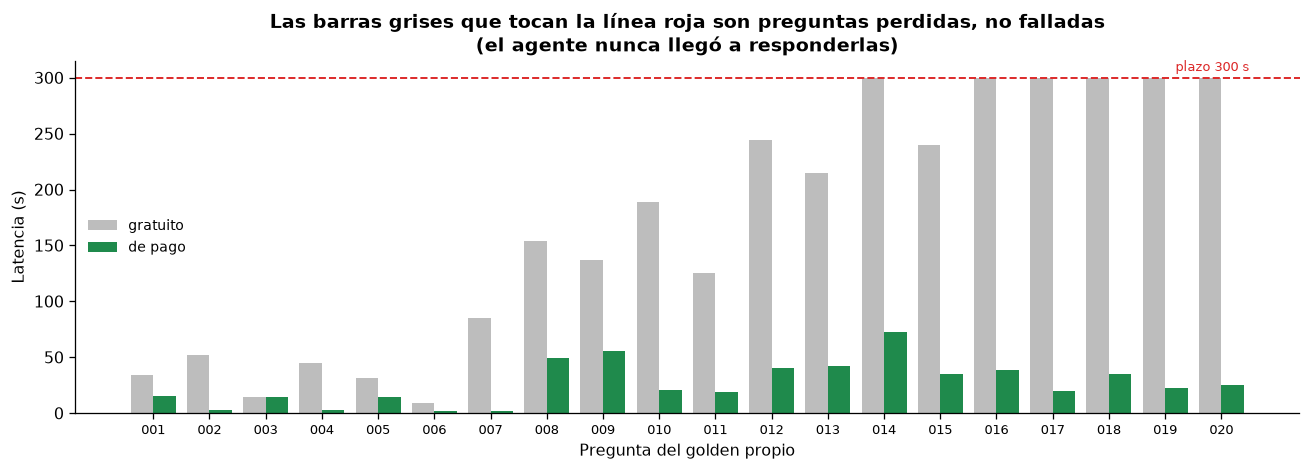

latencia mediana   gratis   171.8 s   ->   pago    21.6 s
latencia p90       gratis   300.0 s   ->   pago    50.1 s


In [10]:
lat_g = {f["id"]: f.get("latencia_s") for f in _leer_jsonl(config.RESULTADOS / "final" / "predicciones.jsonl")}
lat_p = {f["id"]: f.get("latencia_s") for f in _leer_jsonl(config.RESULTADOS / PAGO / "predicciones.jsonl")}
ids = sorted(set(lat_g) & set(lat_p))

if not ids:
    display(Markdown("**Pendiente:** hacen falta las predicciones de las dos tandas para la figura."))
else:
    x = np.arange(len(ids))

    fig, ax = plt.subplots(figsize=(11.5, 4.2))
    ax.bar(x - 0.2, [lat_g.get(i) or 0 for i in ids], 0.4, label="gratuito", color=COLOR_GRATIS)
    ax.bar(x + 0.2, [lat_p.get(i) or 0 for i in ids], 0.4, label="de pago", color=COLOR_PAGO)
    ax.axhline(300, color="#DC2626", linestyle="--", linewidth=1.2)
    ax.text(len(ids) - 0.5, 306, "plazo 300 s", color="#DC2626", fontsize=8, ha="right")
    ax.set_xticks(x, [i.replace("g3-", "") for i in ids], fontsize=8)
    ax.set_xlabel("Pregunta del golden propio")
    ax.set_ylabel("Latencia (s)")
    ax.set_title("Las barras grises que tocan la línea roja son preguntas perdidas, no falladas\n"
                 "(el agente nunca llegó a responderlas)")
    ax.legend(frameon=False, fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

rg, rp = resumen_de(GRATIS), resumen_de(PAGO)
seg = lambda v: "      —" if not isinstance(v, (int, float)) else f"{v:7.1f}"
for clave, titulo in (("latencia_mediana_s", "latencia mediana"), ("latencia_p90_s", "latencia p90")):
    print(f"{titulo:18} gratis {seg(rg.get(clave))} s   ->   pago {seg(rp.get(clave))} s")

## 7. El coste, que por fin es un número

El enunciado pide el coste medio por pregunta como **columna** de la tabla, no como nota al pie. Hasta ahora
esa casilla decía `0,00`, no porque el agente fuera gratis sino porque el proveedor no informaba de nada: el
resumen lo marcaba con la regla `modelo_termina_en_:free_y_sin_costes_reportados`. Con el modelo de pago,
OpenRouter devuelve el coste real de cada petición y la casilla pasa a leerse `metadata_openrouter`.

Es la primera vez que el repo puede responder «¿a qué coste?» con un número medido en vez de con un cero.

In [11]:
filas_coste = []
for etiqueta in ("final", PAGO, "baseline_pago"):
    r = resumen_de(etiqueta)
    if not r:
        continue
    preds = _leer_jsonl(config.RESULTADOS / etiqueta / "predicciones.jsonl")
    total = sum(f.get("usd") or 0 for f in preds)
    filas_coste.append({
        "tanda": etiqueta,
        "modelo": r.get("modelo"),
        "USD/pregunta": r.get("usd_medio"),
        "USD de la tanda": round(total, 4),
        "procedencia": r.get("coste_fuente", "—"),
    })
display(pd.DataFrame(filas_coste).set_index("tanda"))

coste_pago = resumen_de(PAGO).get("usd_medio") or 0
if coste_pago:
    display(Markdown(
        f"A **{coste_pago:.4f} USD por pregunta**, las diez preguntas ciegas del día 24 costarían "
        f"**{10 * coste_pago:.3f} USD** y una tanda completa de 26 preguntas, "
        f"**{26 * coste_pago:.3f} USD**."))

,modelo,USD/pregunta,USD de la tanda,procedencia
tanda,,,,
final,nex-agi/nex-n2.5-pro:free,0.000000,0.0000,https://openrouter.ai/inclusionai/ling-3.0-fla...
final_pago,google/gemini-3.8-flash,0.019097,0.3819,metadata_openrouter
baseline_pago,google/gemini-3.8-flash,0.011758,0.2352,metadata_openrouter


A **0.0191 USD por pregunta**, las diez preguntas ciegas del día 24 costarían **0.191 USD** y una tanda completa de 26 preguntas, **0.497 USD**.

## 8. El par del R11 con el modelo de pago

`final_pago` por sí solo no podría entrar nunca en una tabla del enunciado: compararlo con el baseline
gratuito mezclaría dos variables. Por eso se midió también `baseline_pago`. Con las dos filas medidas con el
mismo modelo, la tabla del R11 vuelve a ser válida y `tabla_r11()` sí marca ganador.

Esto deja al grupo con **dos tablas R11 completas y válidas**, una por proveedor. La entregada sigue siendo
la gratuita; esta queda como anexo y como puerta abierta.

**Salvedad que hay que declarar.** Las cuatro tandas de pago se lanzaron **en paralelo contra la misma clave
de API**, y `baseline_pago` perdió tres preguntas con errores 400 y 429 del proveedor. Un 429 en una cuenta
de pago apunta a contención entre procesos, es decir, a un artefacto de cómo se midió y no a una propiedad
del sistema. Esas tres filas cuentan como fallo, según la regla del repo, y eso **penaliza al baseline y por
tanto favorece a `final_pago`**: la distancia entre las dos filas de esta tabla es, como mucho, la real. No
afecta a la comparación principal del anexo (§4), donde `final_pago` tuvo 0 errores.

Aun así, en las 20 preguntas del golden propio el baseline de pago obtiene **la misma nota que el gratuito**
—7/7, 0/6, 0/7, micro 35 %— pese a tener 3 errores en vez de 7. Sin guardrails, el agente de partida no
aprovecha el mejor proveedor: sigue sin citar bien y sin descomponer comparativas.

**Y un hallazgo que va en contra nuestra, así que hay que contarlo.** En los huecos no pasa lo mismo:
`baseline_pago_huecos` acierta **6/6**, mientras que `baseline_nexn25pro_huecos` se quedaba en 3/6. Es
decir, la subida de 3/6 a 6/6 que el informe atribuye a la regla de universo de los guardrails **también la
consigue el modelo de pago por sí solo, sin ningún guardrail**. El guardrail de huecos no es inútil —con el
proveedor que de verdad usamos, hace falta— pero su mérito no es exclusivo: parte de lo que arregla es
capacidad del modelo. Conviene decirlo antes de que lo pregunten.

(Comprobado que no es un artefacto del código de puntuación: re-puntuadas hoy con `repuntuar()`, las
tandas viejas siguen dando 3/6 y 6/6 respectivamente.)

In [12]:
if all(resumen_de(e) for e in PAR_R11_PAGO):
    r11_pago = evaluacion.tabla_r11(PAR_R11_PAGO)
    display(r11_pago.drop(columns=["recall@5"], errors="ignore"))
    display(Markdown(f"*{r11_pago.attrs['nota']}*"))
else:
    display(Markdown("**Pendiente:** falta alguna de las dos tandas de pago del par R11."))

,sistema,modelo,numérica,extractiva,comparativa,hueco,micro,coste USD/pregunta,latencia media (s),latencia mediana (s),tokens/pregunta,llamadas/pregunta
0,baseline_pago,google/gemini-3.8-flash,7/7,0/6,0/7,6/6,0.35,0.01 *,16.86 *,14.63 *,"12,401.05 *",2.45
1,final_pago,google/gemini-3.8-flash,7/7,4/6,4/7,6/6,0.75 *,0.02,26.58,21.60,"15,092.80",2.20 *


*'*' marca el mejor valor de cada columna.*

**Nota sobre `recall@5`.** La columna se omite en las dos tablas de este cuaderno porque sale vacía para
cualquier etiqueta nueva: `manifest_ejecucion()` ya no escribe el campo `paso_aislado` que
`_recall_aislado()` necesita para localizar el paso en la escalera de retrieval. Es una inconsistencia del
repo, anterior a este anexo, y no se arregla aquí para no invalidar los manifiestos de las tandas ya
medidas. Para esta ablación tampoco sería la columna informativa: el recall aislado mide el buscador, que es
el mismo código determinista en las dos filas. La columna que sí depende del modelo es `recall_agente` —lo
que el agente llegó a recuperar de verdad—, y esa se recoge en §4.

## 9. La respuesta, y la lista de comprobación

**De las ocho preguntas que el sistema entregado falla, cuatro eran del proveedor y cuatro son nuestras.**

Las cuatro del proveedor se recuperan solas al cambiar de modelo, y son exactamente las cuatro que se
quedaron sin respuesta por plazo agotado. Las otras cuatro no las arregla ningún proveedor: dos son un
desacuerdo entre la frase que cita el agente y la que fija el golden, y dos exigen un razonamiento que el
modelo no hace. El techo real del agente hoy es **16 de 20**, y la tanda de pago se queda en 15 por una
pregunta de ruido.

Eso convierte la frase «el límite es la fiabilidad del proveedor» en algo más preciso y más defendible: el
proveedor explica la **mitad** de lo que falla, no todo. La otra mitad es nuestra y está localizada.

Y obliga a matizar una segunda afirmación, esta vez en contra nuestra: la subida de huecos de 3/6 a 6/6 no
es mérito exclusivo del guardrail de universo, porque el baseline con modelo de pago la consigue sin
guardrail ninguno (§8).

- [x] La ablación cambia una sola variable: sistema, golden y retrieval verificados idénticos (§1).
- [x] El juez es el mismo en las dos filas, vía `final_jp`, y no mueve ninguna pregunta (§3).
- [x] Cada pregunta recuperada se corresponde con un `PlazoAgotado` de la tanda gratuita (§5).
- [x] El baseline se re-midió con el mismo modelo, así que el par del R11 es válido (§8).
- [x] El coste por pregunta es un dato del proveedor, no una regla (§7).
- [x] Declarada la salvedad de los errores de `baseline_pago` por concurrencia (§8).
- [ ] Llevar la conclusión al informe como anexo, no a la tabla principal.

**Qué contar en la presentación.** La tabla principal sigue siendo baseline frente a final con el modelo
gratuito: es el sistema entregado y responde a la pregunta del enunciado, si las mejoras mejoraron algo. Este
anexo responde a la siguiente, que es la que nace al mirar esa tabla: de lo que aún falla, cuánto es del
agente y cuánto de quien lo ejecuta. Lo honesto es enseñarlo como diapositiva de reserva y sacarla si alguien
pregunta por las comparativas, que es la pregunta que va a caer.

Vuelta al [07 · Sistema final](07_sistema_final.ipynb) o al [08 · Preguntas ciegas](08_preguntas_ciegas.ipynb).